<a href="https://colab.research.google.com/github/VikaSvyat/DI_Bootcamp/blob/main/Week17/PromptEng_W17_DailyChal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://octopus.developers.institute/courses/collection/124/course/728/section/1996/chapter/4560

Building an agent with LangGraph



 installing and importing the LangGraph SDK and LangChain support for the Gemini API

In [2]:
!pip install -qU "langgraph==1.1.5" "langchain-google-genai==4.1.2" "google-genai==1.66.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.4/169.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.2/732.2 kB 29.5 MB/s eta 0:00:00


In [4]:
import os
from google.colab import userdata
os.environ["GOOGLE_API_KEY"] =  userdata.get('GEMINI_API_KEY')

## Creating the Graph

In [5]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class OrderState(TypedDict):
    """State representing the customer's order conversation."""

    # The chat conversation. This preserves the conversation history
    # between nodes. The `add_messages` annotation indicates to LangGraph
    # that state is updated by appending returned messages, not replacing
    # them.
    messages: Annotated[list, add_messages]

    # The customer's in-progress order.
    order: list[str]

    # Flag indicating that the order is placed and completed.
    finished: bool
# The system instruction defines how the chatbot is expected to behave and includes
# rules for when to call different functions, as well as rules for the conversation, such
# as tone and what is permitted for discussion.
BARISTABOT_SYSINT = (
    "system",  # 'system' indicates the message is a system instruction.
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user) "
    "Always confirm_order with the user (double-check) before calling place_order. Calling confirm_order will "
    "display the order items to the user and returns their response to seeing the list. Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!",
)

# This is the message with which the system opens the conversation.
WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

In [6]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

In [8]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to French. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = model.invoke(messages)
ai_msg

AIMessage(content="J'adore la programmation.", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e35f4-bb9a-7ce3-9d02-4d5bea5e0b8f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 21, 'output_tokens': 7, 'total_tokens': 28, 'input_token_details': {'cache_read': 0}})

the following program defines a chatbot node that will execute a single turn in a chat conversation using the instructions supplied

In [9]:
from langgraph.graph import StateGraph, START, END
# from langchain_google_genai import ChatGoogleGenerativeAI

# Try using different models. The `pro` models perform the best, especially
# with tool-calling. The `flash` models are super fast, and are a good choice
# if you need to use the higher free-tier quota.
# Check out the features and quota differences here: https://ai.google.dev/pricing
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

def chatbot(state: OrderState) -> OrderState:
    """The chatbot itself. A simple wrapper around the model's own chat interface."""
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    return {"messages": [llm.invoke(message_history)]}


# Set up the initial graph based on our state definition.
graph_builder = StateGraph(OrderState)

# Add the chatbot function to the app graph as a node called "chatbot".
graph_builder.add_node("chatbot", chatbot)

# Define the chatbot node as the app entrypoint.
graph_builder.add_edge(START,"chatbot")

chat_graph = graph_builder.compile()

Visualise the graph

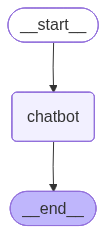

In [10]:
from IPython.display import Image

Image(chat_graph.get_graph().draw_mermaid_png())

## Running the graph

it will transition from start to chatbot, execute the chatbot node, and terminate.

In [11]:
user_msg = ("user", "I want a cappucino please.")
state=chat_graph.invoke({"messages":[user_msg]})

for msg in state["messages"]:
    print(f"{type(msg).__name__} : {msg.content}")

HumanMessage : I want a cappucino please.
AIMessage : Great choice! A Cappuccino coming right up.

Would you like anything else, or are you ready to confirm your order?


This second invocation takes the state from the first call and appends another user message to elicit another response from the chatbot.

Run a second turn by appending another user message

In [33]:
user_msg = ("user", "Actually, make it iced.")
state["messages"].append(user_msg)
state = chat_graph.invoke(state)

for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: I want a cappucino please.
AIMessage: 
AIMessage: Great choice! A Cappuccino is a classic. I'll add one Cappuccino to your order.

Would you like anything else, or are you ready to confirm your order?
AIMessage: 
HumanMessage: Actually, make it iced.
AIMessage: No problem at all! I can certainly make that an Iced Cappuccino for you.

I've updated your order to include one Iced Cappuccino.

Would you like to add anything else, or are you ready to confirm your order?


## Implementing the loop

Instead of repeatedly running the “graph” in a Python loop, you can use LangGraph to loop between nodes.

Add a human node to loop with LangGraph

In [37]:
#
from langchain_core.messages.ai import AIMessage


def human_node(state: OrderState) -> OrderState:
    """Display the last model message to the user, and receive the user's input."""
    last_msg = state["messages"][-1]
    print("Model:", last_msg.content)

    user_input = input("User: ")
    if user_input in {"q", "quit", "exit", "goodbye"}:
        state["finished"] = True

    return state | {"messages": [("user", user_input)]}


def chatbot_with_welcome_msg(state: OrderState) -> OrderState:
    """The chatbot itself. A wrapper around the model's own chat interface."""

    if state.get("messages"):
        new_output = llm.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)

    return state | {"messages": [new_output]}


graph_builder = StateGraph(OrderState)
graph_builder.add_node("chatbot", chatbot_with_welcome_msg)
graph_builder.add_node("human", human_node)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", "human")

Add the conditional edge so the loop can exit

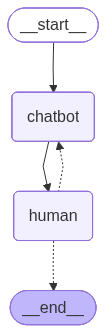

In [39]:
#

def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:
    """Route to the chatbot, unless it looks like the user is exiting."""
    if state.get("finished", False):
        return END
    else:
        return "chatbot"


graph_builder.add_conditional_edges("human", maybe_exit_human_node)
chat_with_human_graph = graph_builder.compile()

Image(chat_with_human_graph.get_graph().draw_mermaid_png())

Conditional edge functions take the state as input, and return a string representing the name of the node to which it will transition.

Add a live menu tool and route tool calls

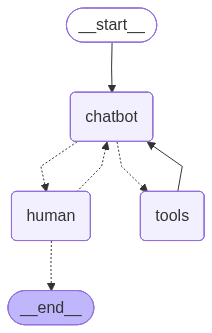

In [41]:
#
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage   # NEW import



@tool
def get_menu() -> str:
    """Provide the latest up-to-date menu."""
    return """
    MENU:
    Coffee Drinks:
    Espresso
    Americano
    Cold Brew

    Coffee Drinks with Milk:
    Latte
    Cappuccino
    Cortado
    Macchiato
    Mocha
    Flat White

    Tea Drinks:
    English Breakfast Tea
    Green Tea
    Earl Grey

    Tea Drinks with Milk:
    Chai Latte
    Matcha Latte
    London Fog

    Other Drinks:
    Steamer
    Hot Chocolate
Modifiers:
    Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free; Default option: whole
    Espresso shots: Single, Double, Triple, Quadruple; default: Double
    Caffeine: Decaf, Regular; default: Regular
    Hot-Iced: Hot, Iced; Default: Hot
    Sweeteners (option to add one or more): vanilla sweetener, hazelnut sweetener, caramel sauce, chocolate sauce, sugar free vanilla sweetener
    Special requests: any reasonable modification that does not involve items not on the menu, for example: 'extra hot', 'one pump', 'half caff', 'extra foam', etc.

    "dirty" means add a shot of espresso to a drink that doesn't usually have it, like "Dirty Chai Latte".
    "Regular milk" is the same as 'whole milk'.
    "Sweetened" means add some regular sugar, not a sweetener.

    Soy milk has run out of stock today, so soy is not available.
  """


# Auto tools + tool routing for menu lookup
auto_tools = [get_menu]
tools_by_name = {t.name: t for t in auto_tools}   # map tool name -> tool object
llm_with_tools = llm.bind_tools(auto_tools)


def tools_node(state: OrderState) -> dict:
    """Execute any tool calls from the last AI message."""
    msgs = state.get("messages", [])
    if not msgs:
        raise ValueError(f"No messages found when parsing state: {state}")

    last = msgs[-1]
    results = []

    # last.tool_calls is populated by llm_with_tools
    for tool_call in getattr(last, "tool_calls", []):
        name = tool_call["name"]
        args = tool_call.get("args", {}) or {}
        tool = tools_by_name[name]

        # @tool objects support .invoke(args)
        observation = tool.invoke(args)

        results.append(
            ToolMessage(
                content=observation,
                tool_call_id=tool_call["id"],
            )
        )

    # LangGraph merges this partial state with the existing state
    return {"messages": results}


def maybe_route_to_tools(state: OrderState) -> Literal["tools", "human"]:
    """Route between human or tool nodes, depending if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    msg = msgs[-1]
    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        return "tools"
    else:
        return "human"


def chatbot_with_tools(state: OrderState) -> OrderState:
    """Chatbot aware of available tools."""
    defaults = {"order": [], "finished": False}

    if state.get("messages"):
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)

    return defaults | state | {"messages": [new_output]}


graph_builder = StateGraph(OrderState)

graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tools_node)   # use our custom node here

graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph_with_menu = graph_builder.compile()
Image(graph_with_menu.get_graph().draw_mermaid_png())


add the new tool to the graph. The get_menu tool is wrapped in a ToolNode that handles calling the tool and passing the response as a message through the graph. The tools are also bound to the llm object so that the underlying model knows they exist. As you now have a different llm object to invoke, you need to update the chatbot node so that it is aware of the tools.

 Add ordering tools that mutate state

In [42]:
#
from collections.abc import Iterable
from random import randint
from langchain_core.messages.tool import ToolMessage


@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Adds the specified drink to the customer's order, including any modifiers."""


@tool
def confirm_order() -> str:
    """Asks the customer if the order is correct."""


@tool
def get_order() -> str:
    """Returns the users order so far. One item per line."""


@tool
def clear_order():
    """Removes all items from the user's order."""


@tool
def place_order() -> int:
    """Sends the order to the barista for fulfillment."""


def order_node(state: OrderState) -> OrderState:
    """The ordering node. This is where the order state is manipulated."""
    tool_msg = state["messages"][-1]
    order = list(state.get("order", []))
    outbound_msgs = []
    order_placed = state.get("finished", False)

    for tool_call in tool_msg.tool_calls:
        if tool_call["name"] == "add_to_order":
            raw_modifiers = tool_call["args"].get("modifiers", [])
            if raw_modifiers is None:
                modifiers = []
            elif isinstance(raw_modifiers, str):
                modifiers = [raw_modifiers]
            else:
                modifiers = list(raw_modifiers)

            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"
            order.append(f'{tool_call["args"]["drink"]} ({modifier_str})')
            response = "".join(order)

        elif tool_call["name"] == "confirm_order":
            print("Your order:")
            if not order:
                print("  (no items)")
            for drink in order:
                print(f"  {drink}")
            response = input("Is this correct? ")

        elif tool_call["name"] == "get_order":
            response = "".join(order) if order else "(no order)"

        elif tool_call["name"] == "clear_order":
            order.clear()
            response = "Order cleared."

        elif tool_call["name"] == "place_order":
            order_text = "".join(order)
            print("Sending order to kitchen!")
            print(order_text)
            order_placed = True
            response = randint(1, 5)

        else:
            raise NotImplementedError(f'Unknown tool call: {tool_call["name"]}')

        outbound_msgs.append(
            ToolMessage(
                content=response,
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}


def maybe_route_to_tools(state: OrderState) -> str:
    """Route between chat and tool nodes if a tool call is made."""
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"No messages found when parsing state: {state}")

    msg = msgs[-1]

    if state.get("finished", False):
        return END
    elif hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        if any(tool["name"] in tool_node.tools_by_name.keys() for tool in msg.tool_calls):
            return "tools"
        else:
            return "ordering"
    else:
        return "human"

Build the full graph with ordering tools

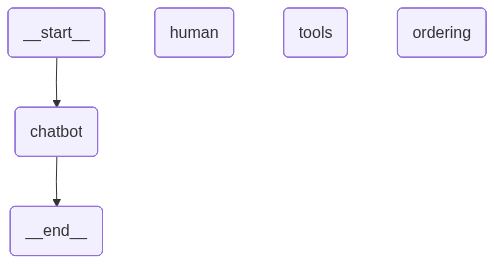

In [45]:
#
from langchain_core.messages import ToolMessage

# Tools
auto_tools = [get_menu]
order_tools = [add_to_order, confirm_order, get_order, clear_order, place_order]

# Registries
menu_tools_by_name = {t.name: t for t in auto_tools}
order_tools_by_name = {t.name: t for t in order_tools}

# The LLM needs to know about all tools
llm_with_tools = llm.bind_tools(auto_tools + order_tools)


def tools_node(state: OrderState) -> dict:
    """Execute menu-related tools like get_menu."""
    messages = state.get("messages", [])
    if not messages:
        raise ValueError(f"No messages found when parsing state: {state}")

    last = messages[-1]
    tool_msgs = []

    for tool_call in getattr(last, "tool_calls", []):
        name = tool_call["name"]
        if name not in menu_tools_by_name:
            continue  # not a menu tool, ignore here
        args = tool_call.get("args", {}) or {}
        tool = menu_tools_by_name[name]
        result = tool.invoke(args)

        tool_msgs.append(
            ToolMessage(
                content=result,
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": tool_msgs}


def ordering_node(state: OrderState) -> dict:
    """Execute ordering tools: add_to_order, confirm_order, etc."""
    messages = state.get("messages", [])
    if not messages:
        raise ValueError(f"No messages found when parsing state: {state}")

    last = messages[-1]
    tool_msgs = []

    for tool_call in getattr(last, "tool_calls", []):
        name = tool_call["name"]
        if name not in order_tools_by_name:
            continue
        args = tool_call.get("args", {}) or {}
        tool = order_tools_by_name[name]
        result = tool.invoke(args)

        tool_msgs.append(
            ToolMessage(
                content=result,
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": tool_msgs}


def maybe_route_to_tools(state: OrderState) -> str:
    """
    Route between:
    - 'tools'      -> menu tools (get_menu)
    - 'ordering'   -> order tools (add_to_order, confirm_order, ...)
    - 'human'      -> human node (no tool calls)
    """
    messages = state.get("messages", [])
    if not messages:
        raise ValueError(f"No messages found when parsing state: {state}")

    msg = messages[-1]
    tool_calls = getattr(msg, "tool_calls", []) or []

    if not tool_calls:
        return "human"

    # Assume one tool call at a time (as in the tutorial)
    name = tool_calls[0]["name"]

    if name in menu_tools_by_name:
        return "tools"
    elif name in order_tools_by_name:
        return "ordering"
    else:
        # Fallback: no recognized tool, hand back to human
        return "human"


# Reuse chatbot_with_tools but now it sees all tools
def chatbot_with_tools(state: OrderState) -> OrderState:
    defaults = {"order": [], "finished": False}
    if state.get("messages"):
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)
    return defaults | state | {"messages": [new_output]}


graph_builder = StateGraph(OrderState)

graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tools_node)
graph_builder.add_node("ordering", ordering_node)

graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("ordering", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph_with_order_tools = graph_builder.compile()
Image(graph_with_order_tools.get_graph().draw_mermaid_png())

Handle orders

## Test run

run the complete ordering system graph.

Run the complete ordering system

In [46]:
#
from pprint import pprint

config = {"recursion_limit": 100}
state = graph_with_order_tools.invoke({"messages": []}, config)

pprint(state)

Model: Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?
User: I'd like americano
Model: [{'type': 'text', 'text': 'You got it! Anything else?', 'extras': {'signature': 'Co0BAQw51sfxEbSwPunJz70Zs9EierKJto2Kdg7Itfn47YJfqgyi/zQdZOTYY+HiKsN3lPpOtj/Ojo87ZiVSW9H4pTKix2pMZZK4Q29vWxcvD4ndv7tsQ08DWuedxqvOqiaYUhaDT2PE1ZJD7SpX4wZstPERAKQZTLx7C3CZ/kumjZJTAOaeGLP0LPKQV8nI'}}]
User: cold
Model: I've added an Iced Americano to your order. Would you like anything else?
User: and latte
Model: One latte added. Anything else?
User: double milk please
Model: [{'type': 'text', 'text': 'I\'m not sure what "double milk" means. We have Whole, 2%, Oat, Almond, and 2% Lactose Free milk options. Which of these would you like, or did you mean something else?', 'extras': {'signature': 'CuMDAQw51seTObKje6Yn5I/ugu0VFnM0gqMVmViguNWGmhZkQTacw/6Ea7pze0mM1xb9AxNM6hXRcwSZJBrZZAq2KzdDE/c42+CJ614ImqMtWb38xvGWRHJpeaM/lDcHWVXTXGQnMQsXbDa8KQ3J7S+laSTzjsUwbkHV2GGi8L0rZLiIdEWFfuU5MVk6as+aMcVovQ49uI4t

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 44.217420942s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT